In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

# a


In [16]:
file = pd.read_csv("./lab2/YearPredictionMSD.txt", header=None, delimiter=',').dropna()

# b

In [17]:
train_df = file.iloc[:463715]
test_df  = file.iloc[463715:]

# c

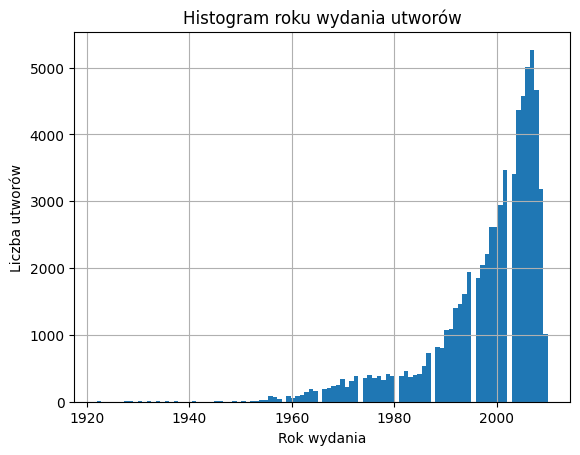

In [18]:
train_df[0].hist(bins=100)
plt.title('Histogram roku wydania utworów')
plt.xlabel('Rok wydania')
plt.ylabel('Liczba utworów')
plt.show()

# d

In [19]:
y_train = train_df.iloc[:, 0].values
X_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
X_test = test_df.iloc[:, 1:].values

A_train = np.c_[np.ones(X_train.shape[0]), X_train]
A_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [20]:
f_min = X_train.min(axis=0)
f_max = X_train.max(axis=0)

denominator_f = np.where((f_max - f_min) == 0, 1, (f_max - f_min))

In [21]:
X_train_scaled = (X_train - f_min) / denominator_f
X_test_scaled = (X_test - f_min) / denominator_f

A_train_scaled = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
A_test_scaled = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

In [22]:

y_min = y_train.min()
y_max = y_train.max()

denominator_y = 1 if (y_max - y_min) == 0 else (y_max - y_min)

y_train_scaled = (y_train - y_min) / denominator_y
y_test_scaled = (y_test - y_min) / denominator_y

# e

In [23]:
def fit_ols(A, y): # ordinary least squares
    M = A.T @ A
    
    v = A.T @ y
    
    w = np.linalg.solve(M, v)
    return w

In [24]:

w_unscaled = fit_ols(A_train, y_train)

w_scaled = fit_ols(A_train_scaled, y_train_scaled)

In [25]:
print(f"Wymiary wektora wag (surowe): {w_unscaled.shape}")
print(f"Wymiary wektora wag (znormalizowane): {w_scaled.shape}")

Wymiary wektora wag (surowe): (91,)
Wymiary wektora wag (znormalizowane): (91,)


# f

In [26]:
def fit_svd(A,y):

    weights,_,_,_ = scipy.linalg.lstsq(A,y)
    return weights

In [30]:
def fit_svd_with_lambda(A,y,lamb):
    I = np.identity(A.shape[1])
    I[0,0] = 0
    M = A.T @ A + lamb*I
    N = A.T @ y

    weights = scipy.linalg.solve(M,N)
    return weights

In [28]:
print(A_train,y_train)

[[ 1.0000000e+00  4.9943570e+01  2.1471140e+01 ... -1.8222300e+00
  -2.7463480e+01  2.2632700e+00]
 [ 1.0000000e+00  4.8732150e+01  1.8429300e+01 ...  1.2049410e+01
   5.8434530e+01  2.6920610e+01]
 [ 1.0000000e+00  5.0957140e+01  3.1856020e+01 ... -5.8590000e-02
   3.9670680e+01 -6.6345000e-01]
 ...
 [ 1.0000000e+00  3.8067190e+01 -7.2077860e+01 ... -1.2868340e+01
  -1.6812829e+02 -2.0727770e+01]
 [ 1.0000000e+00  3.8205150e+01 -2.8014870e+01 ... -2.4807700e+00
   1.0958781e+02  5.4498430e+01]
 [ 1.0000000e+00  3.9640040e+01 -8.0637720e+01 ... -4.8249800e+00
   9.0587640e+01  3.0670800e+00]] [2001 2001 2001 ... 1998 1999 1999]


In [31]:
w_unscaled_svd = fit_svd(A_train, y_train)

lamb = 0.01
w_regularized_svd = fit_svd_with_lambda(A_train, y_train,lamb)

In [34]:
print(f"Wymiary wektora wag (svd): {w_unscaled_svd.shape}")
print(f"Wymiary wektora wag (zregularyzowane równanie normalne): {w_regularized_svd.shape}")


Wymiary wektora wag (svd): (91,)
Wymiary wektora wag (zregularyzowane równanie normalne): (91,)


# g

In [35]:
A_cond_number = np.linalg.cond(A_train.T @ A_train)
A_cond_number_scaled = np.linalg.cond(A_train_scaled.T @ A_train_scaled)

In [36]:
print(f"Współczynnik uwarunkowania macierzy nieznormalizowanej: {A_cond_number}")
print(f"Współczynnik uwarunkowania macierzy znormalizowanej: {A_cond_number_scaled}")

Współczynnik uwarunkowania macierzy nieznormalizowanej: 3881154684.7757607
Współczynnik uwarunkowania macierzy znormalizowanej: 990389.4179150616


In [38]:
print(f"Utrata cyfr znaczących dla macierzy nieznormalizowanej: {np.round(np.log10(A_cond_number))}")
print(f"Utrata cyfr znaczących dla macierzy znormalizowanej: {np.round(np.log10(A_cond_number_scaled))}")

Utrata cyfr znaczących dla macierzy nieznormalizowanej: 10.0
Utrata cyfr znaczących dla macierzy znormalizowanej: 6.0


# h

In [43]:
weights_check_raw = A_train @ w_unscaled
weights_check_scaled = A_train_scaled @ w_scaled

weights_check_scaled_adjusted = weights_check_scaled*(y_max-y_min)+ y_min
error = np.average(abs(weights_check_scaled_adjusted-weights_check_raw))

In [44]:
print(error)

[1997.21422554 1999.51460235 1997.27812682 ... 1993.86370751 2005.27718797
 2001.70201551]
[1997.21422554 1999.51460235 1997.27812682 ... 1993.86370751 2005.27718797
 2001.70201551]
2.8963844809575817e-11


# i